# Hand-wave Demo
**Interactive Quantum Mechanics with Hand Gestures**

## How It Works
1. **ONE HAND (Pinch)**: Creates a Quantum Harmonic Oscillator (QHO)
   - Pinch distance controls the potential curvature
2. **TWO HANDS (Spread)**: Creates a Square Well
   - Hand separation controls the well width

## Instructions
*Have Fun*

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add current directory to path
sys.path.append(os.getcwd())

# Import quantum solver functions
from functions import (
    make_grid, 
    kinetic_operator, 
    solve,
    plot_alive,
    plot_V,plot_dead,
    cheese,
    verify_and_solve
)

# Import camera capture functions
from camera_functions import (
    capture_hand_potential,
    verify_and_plot_capture
)

print("✓ Libraries imported successfully!")

d:\Documents\SFU\PHYS385_Quantum2\CodeProjects\Hand-wave\functions.py:820: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(x[1:-1], psi_shifted, color=color, lw=1.5, label=f"$\psi_{{{n}}}$ (E={E[n]:.2f})")


✓ Libraries imported successfully!


## Step 1: Initialize Grid and Operators

We create a spatial grid and build the kinetic energy operator using finite differences:

$$T = -\frac{\hbar^2}{2m} \frac{d^2}{dx^2}$$

In [2]:
# Grid parameters
xmin = -10
xmax = 10
L = xmax - xmin
N = 1000

# Create grid
x, dx, x_int = make_grid(x_min=xmin, x_max=xmax, N=N)

# Build kinetic operator (using atomic units: ħ=1, m=1)
T = kinetic_operator(len(x_int), dx)

print(f"Grid created: {N} points from {xmin} to {xmax}")
print(f"Grid spacing: dx = {dx:.5f}")
print(f"Kinetic operator: {T.shape[0]}×{T.shape[1]} matrix")

Grid created: 1000 points from -10 to 10
Grid spacing: dx = 0.01998
Kinetic operator: 1000×1000 matrix


## Step 2: Capture Hand Gesture

**Instructions:**
- Position your hand(s) in front of the camera
- **ONE HAND**: Pinch thumb and index finger (QHO)
- **TWO HANDS**: Spread hands apart (Square Well)
- Hold steady until the progress bar fills

The potential will be captured automatically when you hold still.

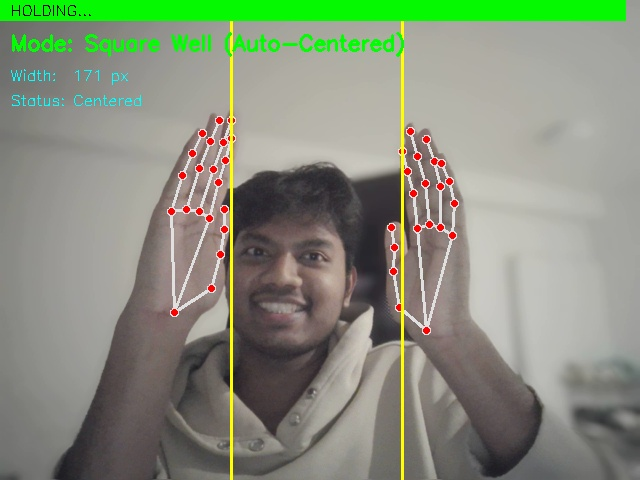

Stable capture triggered and video stream closed.

✓ Potential captured successfully!


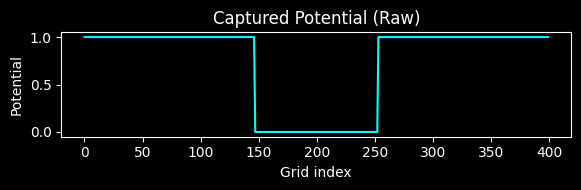

In [18]:
# Capture potential from camera
print("Starting camera...")
print("Hold your hand(s) steady to capture!")
print("")

V_raw = cheese(
    A_MIN=0, 
    A_MAX=500, 
    mode='capcap',  # Requires stability
    max_time=100,      # 30 second timeout
)

if V_raw is not None:
    print("\n✓ Potential captured successfully!")
    
    # Quick preview
    fig = plot_V(V_raw)
    plt.title("Captured Potential (Raw)")
    plt.show()
else:
    print("\n✗ Capture failed or timed out.")

## Step 2a: Interactive Capture with Cheese

This is an alternative capture method using the `cheese` function, which provides a more robust interactive experience.

## Step 3: Solve Schrödinger Equation

We now solve the time-independent Schrödinger equation:

$$\hat{H}\psi = E\psi$$

where $\hat{H} = T + V(x)$ is the Hamiltonian operator.

In [ ]:
# Verify and solve (using V_raw from Step 2)
if 'V_raw' in locals() and V_raw is not None: # Just in case camera didnt work
    E_vals, psi_vecs, V_full = verify_and_plot_capture(
        V_raw, x, dx, T, L
    )

    if E_vals is not None:
        print(f"\n✓ Found {len(E_vals)} energy eigenstates")
        print(f"\nFirst 5 energy levels:")
        for i in range(min(5, len(E_vals))):
            print(f"  E[{i}] = {E_vals[i]:.4f}")
    else:
        print("\n✗ Solver failed.")
else:
    print("No V_raw available. Run Step 2 or 2a first.")

Potential capture successful.
Solver complete. Found 1000 eigenstates.

✓ Found 1000 energy eigenstates

First 5 energy levels:
  E[0] = 0.1661
  E[1] = 0.6645
  E[2] = 1.4949
  E[3] = 2.6571
  E[4] = 4.1507


## Step 4: Visualize Results

Plot the wavefunctions and energy levels.

**Physical Interpretation:**
- **Energy levels** (horizontal lines): Allowed energies
- **Probability density** $|\psi|^2$: Where the particle is likely to be found
- **Nodes**: Points where $\psi = 0$ (higher energy = more nodes)

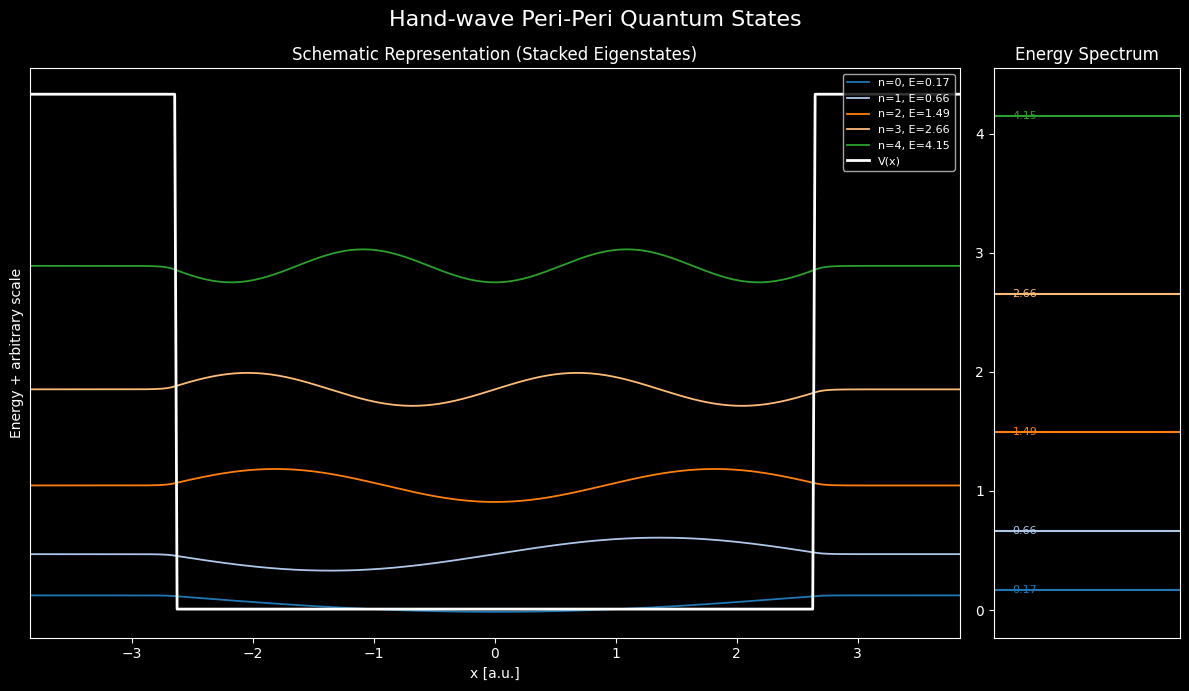


✓ Visualization complete!


In [20]:
# Plot first 5 states
if 'E_vals' in locals() and E_vals is not None:
    fig = plot_dead(
        E_vals, 
        psi_vecs, 
        V_full, 
        x, 
        nos=5,      # Number of states
        mode='wait'  # Show all states
    )
    plt.suptitle("Hand-wave Peri-Peri Quantum States", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete!")
else:
    print("No results to plot.")

## Optional: Analyze Specific State

Choose a specific eigenstate to examine in detail.

## Summary


- Personal Obejctives
1. ✓ Captured a quantum potential using hand gestures
2. ✓ Solved the Schrödinger equation numerically
3. ✓ Visualized the quantum eigenstates

**Try experimenting with:**
- Different hand configurations
- Varying the pinch distance (QHO curvature)
- Changing the well width (Square Well)
- Comparing ground state vs. excited states

**Physics Concepts Demonstrated:**
- Energy quantization
- Wavefunction nodes
- Probability density interpretation
- Quantum tunneling (for finite wells)